In [1]:
import matplotlib.pyplot as plt

from episbi.models import deterministic_seir

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


In [2]:
N  = 100000
E0 = 0
I0 = 100
R0 = 0
S0 = N - E0 - I0 - R0

total_days = 100

init_cond = [S0, E0, I0, R0]

theta = {"beta": 0.3, "kappa": 0.2, "gamma": 0.1}

In [3]:
result = deterministic_seir(
    theta,
    total_days=total_days,
    initial_conditions=init_cond,
    return_compartments=True,
)

incidence = result["data"]
compartments = result["compartments"]
incidence.shape, compartments.shape

((100, 1), (100, 4))

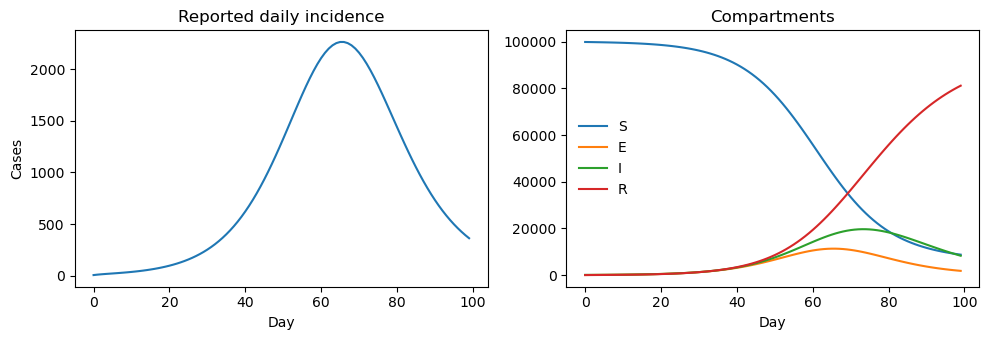

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(incidence[:, 0])
axes[0].set_title("Reported daily incidence")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Cases")

for idx, label in enumerate(["S", "E", "I", "R"]):
    axes[1].plot(compartments[:, idx], label=label)
axes[1].set_title("Compartments")
axes[1].set_xlabel("Day")
axes[1].legend(frameon=False)
fig.tight_layout()